<a href="https://colab.research.google.com/github/SureshRajpoot143/AWS_workshop/blob/main/data_analysis_agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas openpyxl matplotlib

In [ ]:
# Install necessary libraries for Speech Recognition and Text-to-Speech
!apt-get update && apt-get install -y portaudio19-dev espeak-ng
!pip install SpeechRecognition pyttsx3

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
portaudio19-dev is already the newest version (19.6.0-1.1).
espeak-ng is already the newest ve

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Travel details dataset.csv to Travel details dataset.csv


In [ ]:
import pandas as pd

df = pd.read_csv(
    "Travel details dataset.csv"
)

df.head()

,Trip ID,Destination,Start date,End date,Duration (days),Traveler name,Traveler age,Traveler gender,Traveler nationality,Accommodation type,Accommodation cost,Transportation type,Transportation cost
0,1,"London, UK",5/1/2023,5/8/2023,7.0,John Smith,35.0,Male,American,Hotel,1200,Flight,600
1,2,"Phuket, Thailand",6/15/2023,6/20/2023,5.0,Jane Doe,28.0,Female,Canadian,Resort,800,Flight,500
2,3,"Bali, Indonesia",7/1/2023,7/8/2023,7.0,David Lee,45.0,Male,Korean,Villa,1000,Flight,700
3,4,"New York, USA",8/15/2023,8/29/2023,14.0,Sarah Johnson,29.0,Female,British,Hotel,2000,Flight,1000
4,5,"Tokyo, Japan",9/10/2023,9/17/2023,7.0,Kim Nguyen,26.0,Female,Vietnamese,Airbnb,700,Train,200


In [ ]:
import speech_recognition as sr
import os

r = sr.Recognizer()

# --- Using an audio file for speech recognition ---
# You will need to upload a .wav audio file to your Colab environment.
# For example, if you upload 'your_audio_file.wav', ensure it's present.

audio_file_name = 'your_audio_file.wav' # Replace with your audio file name

# Create a dummy audio file path; in a real scenario, you'd upload your own.
# For demonstration, we'll assume a file might not be present and provide a default query.
if not os.path.exists(audio_file_name):
    print(f"Warning: '{audio_file_name}' not found. Please upload a .wav file for actual speech recognition.")
    query = "What are the unique destinations?" # Default query for testing without audio
else:
    with sr.AudioFile(audio_file_name) as source:
        print(f"Processing audio from {audio_file_name}...")
        audio = r.record(source)  # read the entire audio file
    try:
        query = r.recognize_google(audio)
    except sr.UnknownValueError:
        query = "Could not understand audio"
    except sr.RequestError as e:
        query = f"Could not request results from Google Speech Recognition service; {e}"

print(f"Recognized query: {query}")

Recognized query: What are the unique destinations?


In [ ]:
import pandas as pd

# Ensure df is available; this assumes it was loaded in a previous cell (e.g., d05vSbnJPvVb)
if 'df' not in globals():
    print("DataFrame 'df' not found. Please ensure your data loading cell has run.")
    # Optionally load a dummy df or handle error appropriately
    # df = pd.DataFrame({'Destination': ['Paris'], 'Gender': ['Male']})

print("\n--- Data Analysis Q&A ---")

# Use the 'query' variable from the speech recognition cell
user_question = query

response = ""

# Example Q&A logic, expand as needed
if "unique destinations" in user_question.lower() and 'Destination' in df.columns:
    unique_destinations = df['Destination'].unique().tolist()
    response = f"The unique destinations are: {', '.join(map(str, unique_destinations))}."
elif "number of rows" in user_question.lower() or "how many entries" in user_question.lower():
    response = f"There are {len(df)} entries in the dataset."
elif "columns" in user_question.lower() or "fields" in user_question.lower():
    response = f"The columns in the dataset are: {', '.join(df.columns.tolist())}."
elif "male travelers" in user_question.lower():
    male_travelers = df[df['Traveler gender'].astype(str).str.lower() == 'male'].shape[0]
    response = f"There are {male_travelers} male travelers in the dataset."
elif "female travelers" in user_question.lower():
    female_travelers = df[df['Traveler gender'].astype(str).str.lower() == 'female'].shape[0]
    response = f"There are {female_travelers} female travelers in the dataset."
else:
    response = "I can currently answer questions about unique destinations, the number of entries, columns, and male or female travelers. Please rephrase your question."

print(f"User asked: {user_question}")
print(f"Response: {response}")

# This variable will be used by the text-to-speech cell for 'replying'
current_response_for_tts = response


--- Data Analysis Q&A ---
User asked: What are the unique destinations?
Response: The unique destinations are: London, UK, Phuket, Thailand, Bali, Indonesia, New York, USA, Tokyo, Japan, Paris, France, Sydney, Australia, Rio de Janeiro, Brazil, Amsterdam, Netherlands, Dubai, United Arab Emirates, Cancun, Mexico, Barcelona, Spain, Honolulu, Hawaii, Berlin, Germany, Marrakech, Morocco, Edinburgh, Scotland, Paris, Bali, London, Tokyo, New York, Sydney, Rome, Bangkok, Hawaii, Barcelona, Japan, Thailand, France, Australia, Brazil, Greece, Egypt, Mexico, Italy, Spain, Canada, New York City, USA, Bangkok, Thailand, Vancouver, Canada, Sydney, AUS, Seoul, South Korea, Los Angeles, USA, Rome, Italy, Cape Town, nan, Cape Town, SA, Sydney, Aus, Bangkok, Thai, Phuket, Thai, Dubai, Seoul, Rio de Janeiro, Amsterdam, Phuket, Santorini, Phnom Penh, Athens, Greece, Cape Town, South Africa, Auckland, New Zealand.


In [ ]:
import pyttsx3

engine = pyttsx3.init()

# Use the 'current_response_for_tts' variable generated by the Q&A system
answer = current_response_for_tts

print(f"Speaking: {answer}")
engine.say(answer)
engine.runAndWait()

print("Text-to-speech complete.")

Speaking: The unique destinations are: London, UK, Phuket, Thailand, Bali, Indonesia, New York, USA, Tokyo, Japan, Paris, France, Sydney, Australia, Rio de Janeiro, Brazil, Amsterdam, Netherlands, Dubai, United Arab Emirates, Cancun, Mexico, Barcelona, Spain, Honolulu, Hawaii, Berlin, Germany, Marrakech, Morocco, Edinburgh, Scotland, Paris, Bali, London, Tokyo, New York, Sydney, Rome, Bangkok, Hawaii, Barcelona, Japan, Thailand, France, Australia, Brazil, Greece, Egypt, Mexico, Italy, Spain, Canada, New York City, USA, Bangkok, Thailand, Vancouver, Canada, Sydney, AUS, Seoul, South Korea, Los Angeles, USA, Rome, Italy, Cape Town, nan, Cape Town, SA, Sydney, Aus, Bangkok, Thai, Phuket, Thai, Dubai, Seoul, Rio de Janeiro, Amsterdam, Phuket, Santorini, Phnom Penh, Athens, Greece, Cape Town, South Africa, Auckland, New Zealand.
Text-to-speech complete.


In [ ]:
male_df = df[
    df["Traveler gender"] == "Male"
]

male_analysis = (
    male_df["Destination"]
    .value_counts()
    .reset_index()
)

male_analysis.columns = [
    "Destination",
    "Count"
]

male_analysis

,Destination,Count
0,"Paris, France",5
1,Sydney,5
2,"London, UK",3
3,Bali,3
4,"Rio de Janeiro, Brazil",3
5,New York,3
6,"Tokyo, Japan",3
7,Bangkok,3
8,"Rome, Italy",3
9,Paris,3


In [ ]:
female_df = df[
    df["Traveler gender"] == "Female"
]

female_analysis = (
    female_df["Destination"]
    .value_counts()
    .reset_index()
)

female_analysis.columns = [
    "Destination",
    "Count"
]

female_analysis

,Destination,Count
0,"Tokyo, Japan",4
1,Paris,4
2,"Bali, Indonesia",4
3,Bali,4
4,Rome,4
5,London,3
6,"Barcelona, Spain",3
7,Tokyo,3
8,"Bangkok, Thailand",2
9,"Amsterdam, Netherlands",2


In [ ]:
df["Accommodation cost"] = pd.to_numeric(df["Accommodation cost"], errors='coerce')
df["Transportation cost"] = pd.to_numeric(df["Transportation cost"], errors='coerce')

df["Total Budget"] = (
    df["Accommodation cost"]
    +
    df["Transportation cost"]
)

budget_analysis = (
    df.groupby("Destination")
    ["Total Budget"]
    .mean()
    .reset_index()
)

budget_analysis

,Destination,Total Budget
0,Amsterdam,NaN
1,"Amsterdam, Netherlands",1600.000000
2,"Athens, Greece",1600.000000
3,"Auckland, New Zealand",9500.000000
4,Australia,NaN
5,Bali,2900.000000
6,"Bali, Indonesia",1533.333333
7,Bangkok,1000.000000
8,"Bangkok, Thai",NaN
9,"Bangkok, Thailand",1775.000000


In [ ]:
transport_analysis = (

    df["Transportation type"]

    .value_counts()

    .reset_index()

)

transport_analysis.columns = [

    "Transport",

    "Count"

]

transport_analysis

,Transport,Count
0,Plane,57
1,Train,37
2,Flight,13
3,Car rental,13
4,Bus,6
5,Airplane,5
6,Car,3
7,Subway,1
8,Ferry,1


In [ ]:
hotel_analysis = (

    df["Accommodation type"]

    .value_counts()

    .reset_index()

)

hotel_analysis.columns = [

    "Accommodation",

    "Count"

]

hotel_analysis

,Accommodation,Count
0,Hotel,60
1,Airbnb,30
2,Hostel,24
3,Resort,14
4,Villa,4
5,Vacation rental,3
6,Riad,1
7,Guesthouse,1


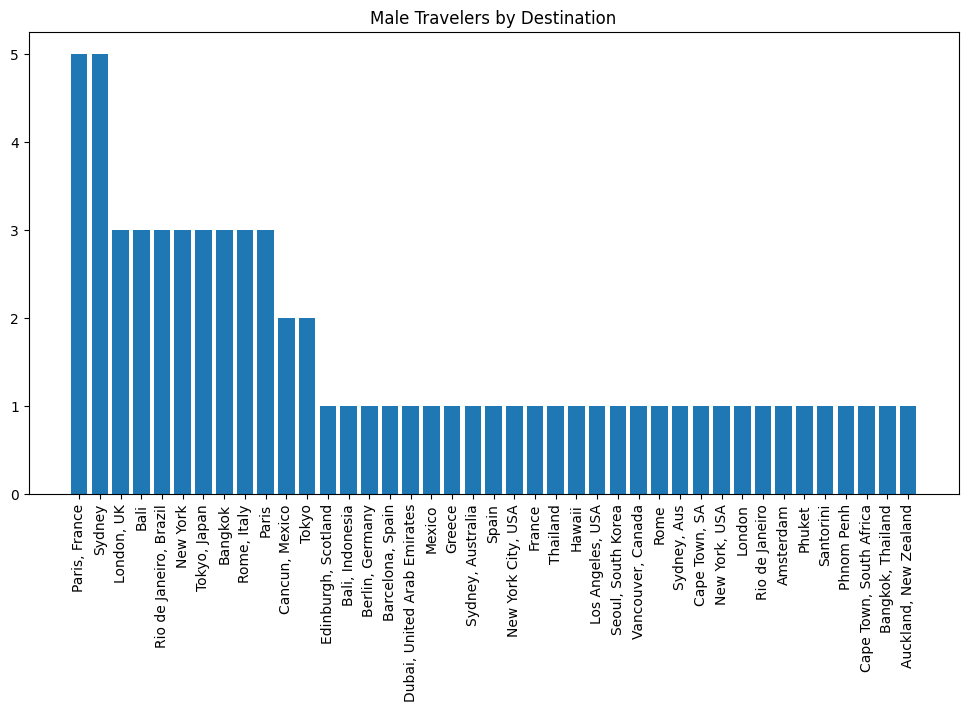

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(

    male_analysis["Destination"],

    male_analysis["Count"]

)

plt.xticks(rotation=90)

plt.title(

    "Male Travelers by Destination"

)

plt.show()

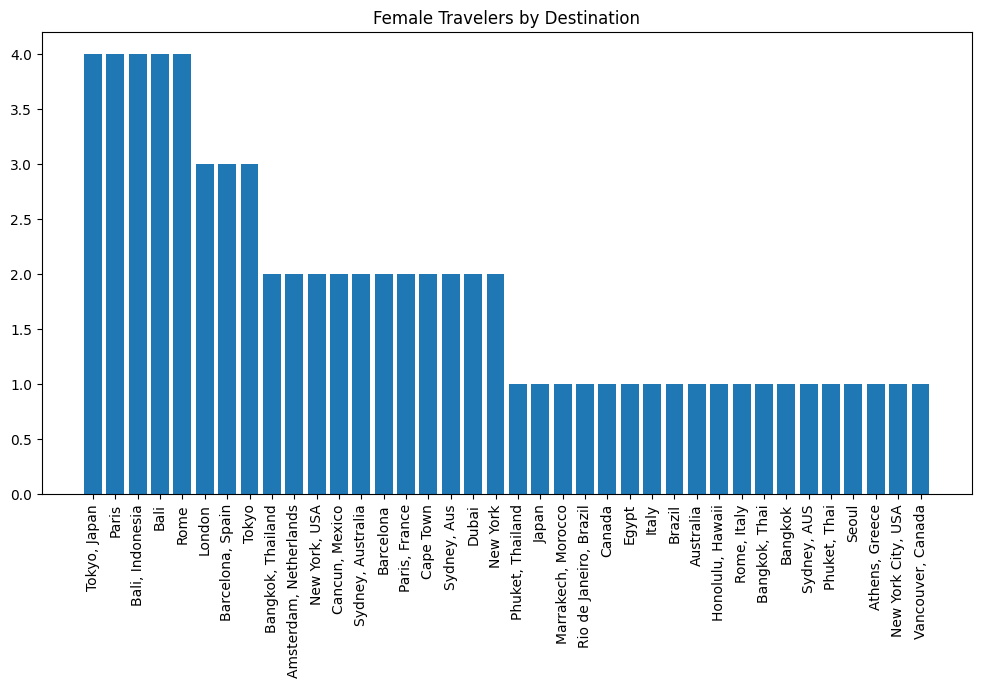

In [ ]:
plt.figure(figsize=(12,6))

plt.bar(

    female_analysis["Destination"],

    female_analysis["Count"]

)

plt.xticks(rotation=90)

plt.title(

    "Female Travelers by Destination"

)

plt.show()

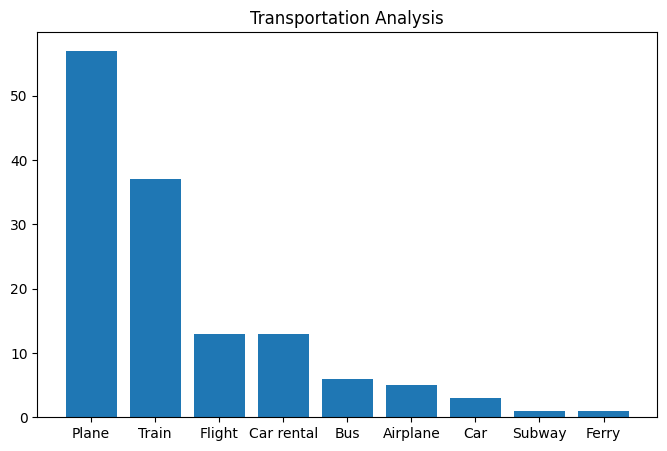

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(

    transport_analysis["Transport"],

    transport_analysis["Count"]

)

plt.title(

    "Transportation Analysis"

)

plt.show()

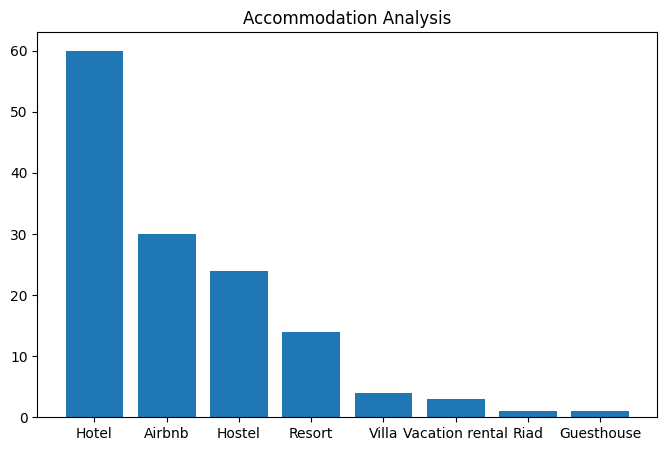

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(

    hotel_analysis["Accommodation"],

    hotel_analysis["Count"]

)

plt.title(

    "Accommodation Analysis"

)

plt.show()

In [ ]:
male_analysis.to_excel(

    "men_analysis.xlsx",

    index=False

)

female_analysis.to_excel(

    "women_analysis.xlsx",

    index=False

)

budget_analysis.to_excel(

    "budget_analysis.xlsx",

    index=False

)

transport_analysis.to_excel(

    "transport_analysis.xlsx",

    index=False

)

hotel_analysis.to_excel(

    "hotel_analysis.xlsx",

    index=False

)

print("Excel Files Created")

Excel Files Created


In [ ]:
from google.colab import files

files.download(
    "men_analysis.xlsx"
)

files.download(
    "women_analysis.xlsx"
)

files.download(
    "budget_analysis.xlsx"
)

files.download(
    "transport_analysis.xlsx"
)

files.download(
    "hotel_analysis.xlsx"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>